# Phase 6: Long Short-Term Memory (LSTM) for 15-Minute AQ Prediction

This notebook trains an LSTM model for high-frequency air quality prediction.

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Load data
X_train = np.load('X_train_15T.npy')
X_test = np.load('X_test_15T.npy')
y_train = pd.read_csv('y_train_15T.csv')['target_pm2_5'].values
y_test = pd.read_csv('y_test_15T.csv')['target_pm2_5'].values
scaler = joblib.load('scaler_15T.pkl')
feature_names = joblib.load('feature_names_15T.pkl')

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Features: {feature_names}")

Train shape: (6741, 12), Test shape: (1686, 12)
Features: ['hour_of_day', 'day_of_week', 'minute_of_hour', 'pm2_5_lag_15m', 'pm2_5_lag_30m', 'pm2_5_lag_45m', 'pm2_5_lag_60m', 'temperature_lag_15m', 'humidity_lag_15m', 'pm10_lag_15m', 'pm2_5_roll_avg_1h', 'temperature_roll_avg_1h']


In [3]:
# 3D Reshaping Utility for DL Models
def reshape_for_dl(X, time_steps=4):
    """
    Reshape 2D data to 3D for deep learning models.
    Adds time dimension for sequence modeling.
    """
    samples = X.shape[0] - time_steps + 1
    features = X.shape[1]
    X_reshaped = np.zeros((samples, time_steps, features))
    
    for i in range(samples):
        X_reshaped[i] = X[i:i+time_steps]
    
    return X_reshaped

# Reshape data
time_steps = 4  # 1 hour lookback (4 * 15min)
X_train_dl = reshape_for_dl(X_train, time_steps)
X_test_dl = reshape_for_dl(X_test, time_steps)

# Adjust y for the reshaping
y_train_dl = y_train[time_steps-1:]
y_test_dl = y_test[time_steps-1:]

print(f"DL Train shape: {X_train_dl.shape}, DL Test shape: {X_test_dl.shape}")
print(f"DL y_train shape: {y_train_dl.shape}, DL y_test shape: {y_test_dl.shape}")

DL Train shape: (6738, 4, 12), DL Test shape: (1683, 4, 12)
DL y_train shape: (6738,), DL y_test shape: (1683,)


In [4]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_dl, dtype=torch.float32).view(-1, 1).to(device)
X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_dl, dtype=torch.float32).view(-1, 1).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])  # Take the last time step
        out = self.fc(out)
        return out

# Initialize model
input_size = X_train_dl.shape[2]
hidden_size = 50
num_layers = 2
output_size = 1
model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMModel(
  (lstm): LSTM(12, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [6]:
# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# Training loop
num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses.append(epoch_train_loss / len(train_loader))
    
    # Validation
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()
    val_losses.append(epoch_val_loss / len(test_loader))
    
    scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

print('Training completed')

Epoch [10/100], Train Loss: 8.2034, Val Loss: 0.3249
Epoch [20/100], Train Loss: 6.4468, Val Loss: 0.2276
Epoch [30/100], Train Loss: 6.2317, Val Loss: 0.1801
Epoch [40/100], Train Loss: 6.0636, Val Loss: 0.1820
Epoch [50/100], Train Loss: 5.7353, Val Loss: 0.4955
Epoch [60/100], Train Loss: 5.5882, Val Loss: 0.1143
Epoch [70/100], Train Loss: 5.4197, Val Loss: 0.2103
Epoch [80/100], Train Loss: 5.3305, Val Loss: 0.1421
Epoch [90/100], Train Loss: 4.9939, Val Loss: 0.1329
Epoch [100/100], Train Loss: 5.1049, Val Loss: 0.2130
Training completed


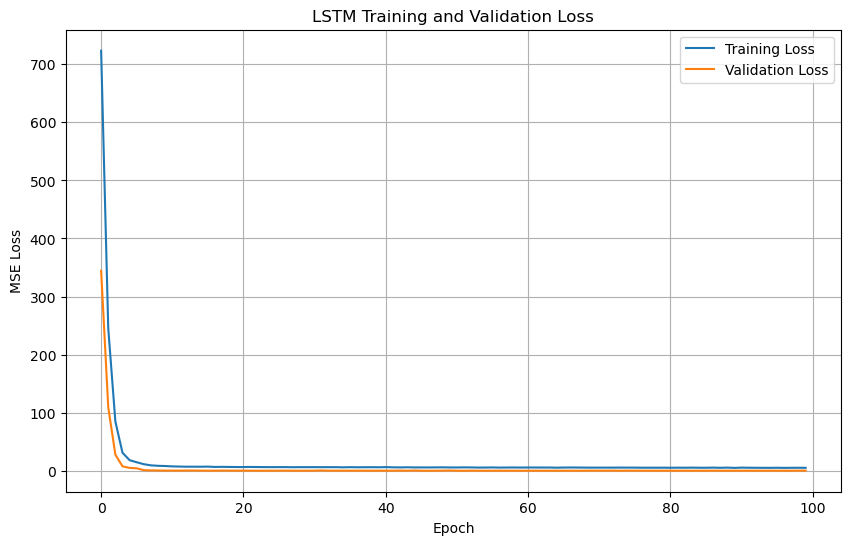

In [7]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Evaluation
model.eval()
y_pred = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        y_pred.extend(outputs.cpu().numpy().flatten())

y_pred = np.array(y_pred)
y_true = y_test_dl

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f'LSTM Test Metrics:')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')

# Results dict
lstm_result = {
    'Model': 'LSTM',
    'RMSE': round(rmse, 4),
    'MAE': round(mae, 4),
    'R2': round(r2, 4)
}

LSTM Test Metrics:
RMSE: 0.4617
MAE: 0.3683
R2: 0.9576


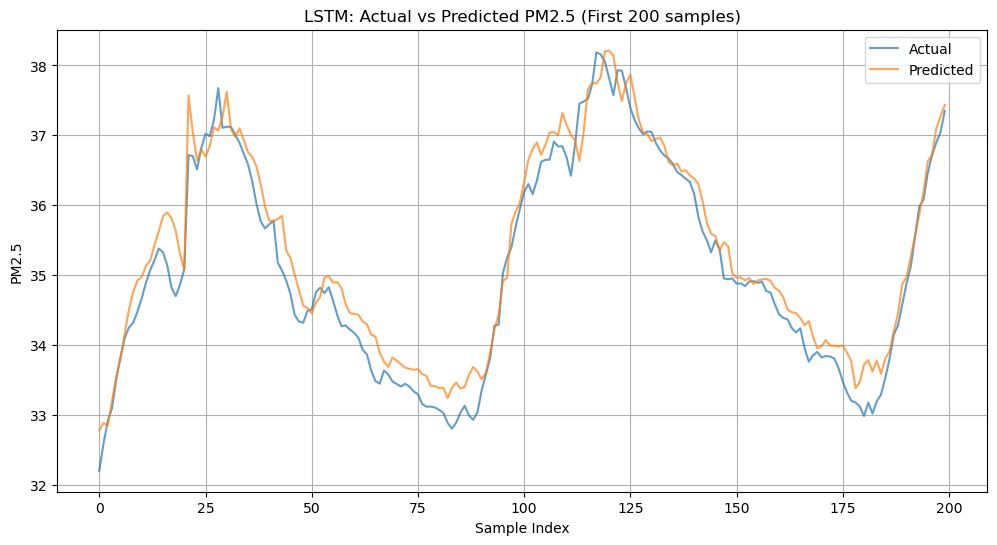

In [9]:
# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(y_true[:200], label='Actual', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('PM2.5')
plt.title('LSTM: Actual vs Predicted PM2.5 (First 200 samples)')
plt.legend()
plt.grid(True)
plt.show()

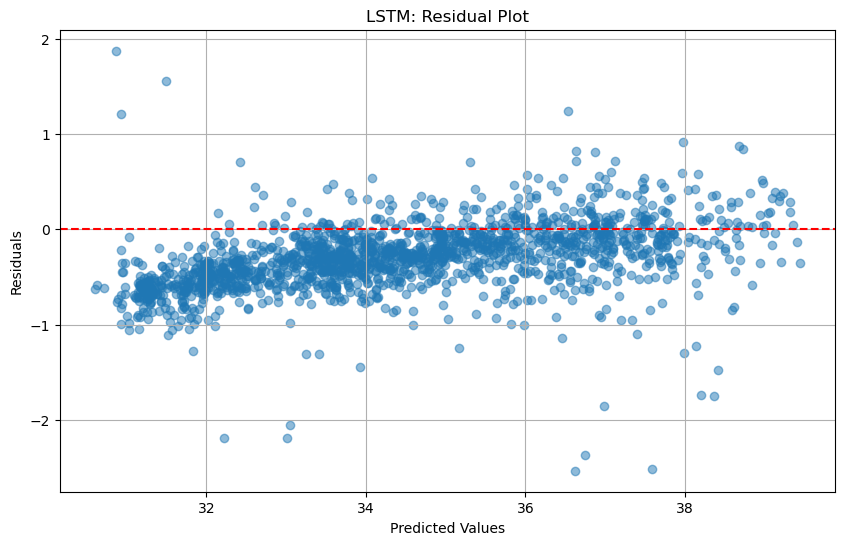

In [10]:
# Residual plot
residuals = y_true - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('LSTM: Residual Plot')
plt.grid(True)
plt.show()

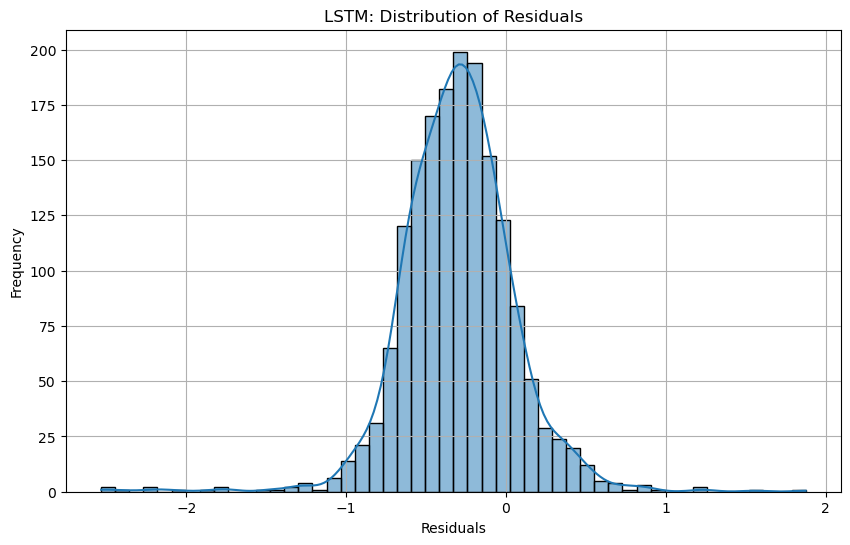

In [11]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('LSTM: Distribution of Residuals')
plt.grid(True)
plt.show()

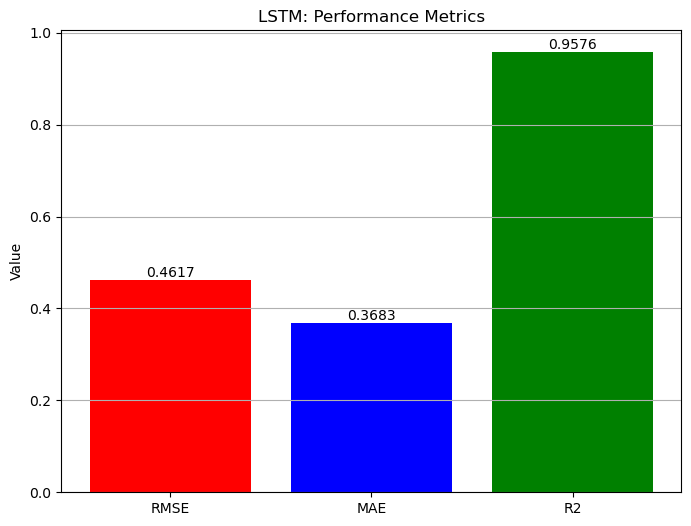

In [12]:
# Metrics bar chart
metrics = ['RMSE', 'MAE', 'R2']
values = [rmse, mae, r2]
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=['red', 'blue', 'green'])
plt.ylabel('Value')
plt.title('LSTM: Performance Metrics')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.4f}', ha='center', va='bottom')
plt.grid(True, axis='y')
plt.show()

In [13]:
# Save model
torch.save(model.state_dict(), 'lstm_model.pth')
print('Model saved as lstm_model.pth')

# Update results.csv
results_df = pd.read_csv('results.csv')
results_df = results_df.append(lstm_result, ignore_index=True)
results_df.to_csv('results.csv', index=False)
print('Results updated in results.csv')
print(results_df)

Model saved as lstm_model.pth


AttributeError: 'DataFrame' object has no attribute 'append'